<a href="https://colab.research.google.com/github/swarnamukhi/computer-vision-with-cnn/blob/main/notebooks/01_Image_Dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/AI-DEEP learning')

['AI_MOR.ipynb',
 'encoder_decoder-Khushi.ipynb',
 'Bahdanau Attention.ipynb',
 'assignment2.ipynb',
 'CNN mnist data.ipynb',
 'LSTM classification.ipynb',
 'Amazon sentiment analysis',
 'MNIST Data',
 'fashion mnist',
 'NER',
 'hugging face',
 'CNN Cats and Dogs']

In [4]:
# =====================================================
# SECTION 1 : IMPORT LIBRARIES
# =====================================================

import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import random
from collections import Counter


In [5]:
# =====================================================
# SECTION 2 : DATASET PATH
# =====================================================

DATASET_PATH = Path("/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs")

In [6]:
dir(DATASET_PATH )

['__bytes__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__fspath__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rtruediv__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__truediv__',
 '_drv',
 '_flavour',
 '_format_parsed_parts',
 '_from_parsed_parts',
 '_hash',
 '_lines',
 '_lines_cached',
 '_load_parts',
 '_make_child_relpath',
 '_parse_path',
 '_parts_normcase',
 '_parts_normcase_cached',
 '_raw_paths',
 '_root',
 '_scandir',
 '_str',
 '_str_normcase',
 '_str_normcase_cached',
 '_tail',
 '_tail_cached',
 'absolute',
 'anchor',
 'as_posix',
 'as_uri',
 'chmod',
 'cwd',
 'drive',
 'exists',
 'expanduser',
 'glob',
 'group',
 'hardlink_to',
 'home',
 'is_absolute',
 'is_block_device',
 'is_char_device',
 'is_dir'

Path objects make file operations cleaner and work well across operating systems.

In [7]:
# =====================================================
# SECTION 3 : VERIFY DATASET
# =====================================================

print("Dataset Exists :", DATASET_PATH.exists())
print("Dataset Path   :", DATASET_PATH)

Dataset Exists : True
Dataset Path   : /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs


In [8]:
for folder in DATASET_PATH.iterdir():
  print(folder)

/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs
/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/cats


In [9]:
classes=[folder.name for folder in DATASET_PATH.iterdir() if folder.is_dir()]
classes

['dogs', 'cats']

In [10]:
# =====================================================
# SECTION 5 : COUNT IMAGES PER CLASS
# =====================================================

for class_name in classes:

    class_path = DATASET_PATH / class_name

    image_count = len(list(class_path.iterdir()))

    print(f"{class_name} : {image_count} images")

dogs : 1008 images
cats : 1000 images


In [11]:
# =====================================================
# SECTION 7 : INSPECT A SAMPLE IMAGE
# =====================================================

sample_image = next((DATASET_PATH / "cats").iterdir())

print("Image Path :", sample_image)

image = Image.open(sample_image)

print("Image Size :", image.size)
print("Color Mode :", image.mode)
print("Image Format :", image.format)


Image Path : /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/cats/cat.986.jpg
Image Size : (500, 374)
Color Mode : RGB
Image Format : JPEG


Pillow is a Python image-processing library that allows us to open, read, inspect, modify, and save image files. It converts image files into Python image objects so they can be processed programmatically."

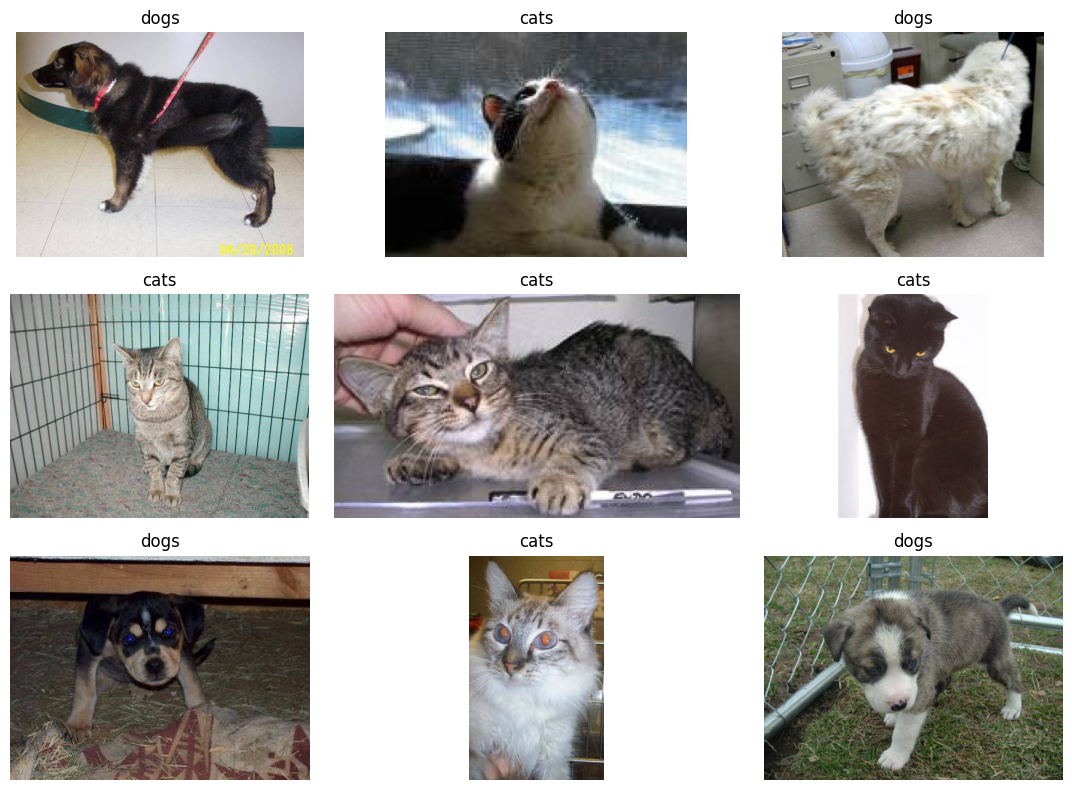

In [12]:
num_images=9
plt.figure(figsize=(12,8))
for i in range(num_images):
    choice = random.choice(classes)
    path=DATASET_PATH/choice
    imagepath =random.choice(list(path.iterdir()))
    image =Image.open(imagepath)
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(choice)
    plt.axis('off')
    plt.tight_layout()
plt.show()


Dataset Inspection Report

--------------------------------

Classes

✓ Cats
✓ Dogs

--------------------------------

Images

Cats : 1000

Dogs : 1000

Balanced : Yes

--------------------------------

Visual Inspection

✓ Labels Correct

✓ Images Clear

✓ Object Visible

--------------------------------

Next Inspection

□ Image Sizes

□ Color Modes

□ Formats

□ Corrupted Images

□ Resolution Statistics

--------------------------------

Conclusion

Dataset appears suitable for preprocessing.

In [13]:
image_width =[]
image_height=[]
for folder in classes:
  class_path=DATASET_PATH/folder
  for image_path in class_path.iterdir():
    image=Image.open(image_path)
    image_width.append(image.width)
    image_height.append(image.height)
print("IMAGE SIZE ANALYSIS")
print("*"*50)
print(f"min width of the image is {min(image_width)}")
print(f"max width of the image is {max(image_width)}")
print(f"AVG width of the image is {sum(image_width)/len(image_width):.2f}")
print("="*50)
print(f"min height of the image is {min(image_height)}")
print(f"max height of the image is {max(image_height)}")
print(f"AVG height of the image is {sum(image_height)/len(image_height):.2f}")

IMAGE SIZE ANALYSIS
**************************************************
min width of the image is 59
max width of the image is 1023
AVG width of the image is 403.78
min height of the image is 50
max height of the image is 768
AVG height of the image is 358.70


In [14]:
color_mode=[]
for folder in classes:
  class_path =DATASET_PATH/folder
  for image_path in class_path.iterdir():
    image =Image.open(image_path)
    color_mode.append(image.mode)
print("*"*50)
print("image mode analysis")
mode_count=Counter(color_mode)
for mode,count in mode_count.items():
    print(f"mode:{mode} count{count}")


**************************************************
image mode analysis
mode:RGB count2008


In [15]:
image_format=[]
for folder in classes:
  class_path =DATASET_PATH/folder
  for image_path in class_path.iterdir():
    image =Image.open(image_path)
    image_format.append(image.format)
print("*"*50)
print("image format analysis")
mode_count=Counter(image_format)
for format,count in mode_count.items():
    print(f"format:{format} count{count}")


**************************************************
image format analysis
format:JPEG count2008


In [16]:
# =====================================================
# SECTION 12 : CORRUPTED IMAGE ANALYSIS
# =====================================================

corrupted_images = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        try:

            image = Image.open(image_path)

            image.verify()

        except Exception:

            corrupted_images.append(image_path)

print("=" * 50)
print("CORRUPTED IMAGE ANALYSIS")
print("=" * 50)

print(f"Total Corrupted Images : {len(corrupted_images)}")

if corrupted_images:

    print("\nCorrupted Images:")

    for img in corrupted_images:
        print(img)

else:

    print("No corrupted images found.")

CORRUPTED IMAGE ANALYSIS
Total Corrupted Images : 0
No corrupted images found.


In [17]:
# =====================================================
# SECTION 13 : ASPECT RATIO ANALYSIS
# =====================================================

aspect_ratios = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        image = Image.open(image_path)

        width, height = image.size

        aspect_ratio = width / height

        aspect_ratios.append(aspect_ratio)

print("=" * 50)
print("ASPECT RATIO ANALYSIS")
print("=" * 50)

print(f"Minimum Aspect Ratio : {min(aspect_ratios):.2f}")
print(f"Maximum Aspect Ratio : {max(aspect_ratios):.2f}")
print(f"Average Aspect Ratio : {sum(aspect_ratios)/len(aspect_ratios):.2f}")

ASPECT RATIO ANALYSIS
Minimum Aspect Ratio : 0.38
Maximum Aspect Ratio : 2.77
Average Aspect Ratio : 1.16


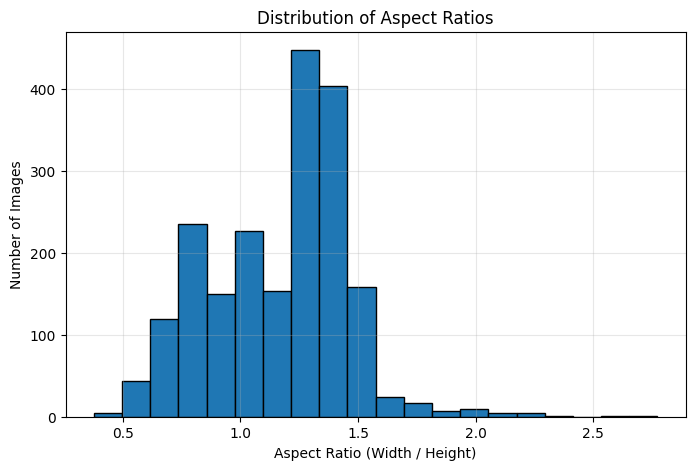

In [18]:
# =====================================================
# SECTION 14 : ASPECT RATIO HISTOGRAM
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    aspect_ratios,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Aspect Ratios")

plt.xlabel("Aspect Ratio (Width / Height)")

plt.ylabel("Number of Images")

plt.grid(alpha=0.3)

plt.show()

Most images have aspect ratios close to 1.

A few images are wider or taller than average.

Resizing to a fixed size (e.g., 224×224) is reasonable.

In [19]:
# =====================================================
# SECTION 15 : FILE SIZE ANALYSIS
# =====================================================

import os

file_sizes = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        # File size in KB
        size_kb = os.path.getsize(image_path) / 1024

        file_sizes.append(size_kb)

print("=" * 50)
print("FILE SIZE ANALYSIS")
print("=" * 50)

print(f"Minimum File Size : {min(file_sizes):.2f} KB")
print(f"Maximum File Size : {max(file_sizes):.2f} KB")
print(f"Average File Size : {sum(file_sizes)/len(file_sizes):.2f} KB")

FILE SIZE ANALYSIS
Minimum File Size : 1.48 KB
Maximum File Size : 91.14 KB
Average File Size : 22.26 KB


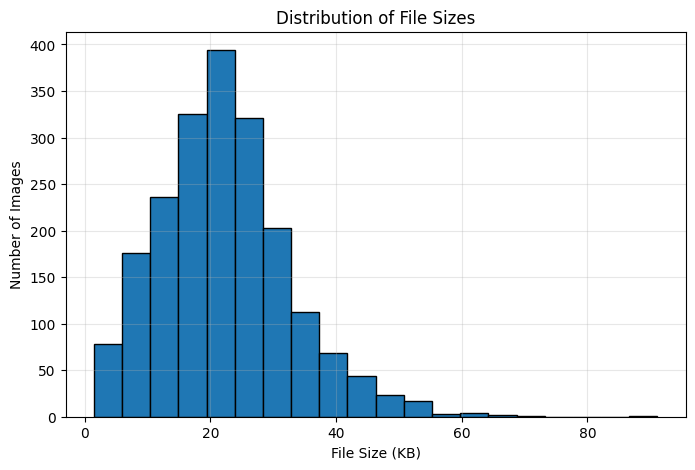

In [20]:
# =====================================================
# SECTION 16 : FILE SIZE HISTOGRAM
# =====================================================

plt.figure(figsize=(8,5))

plt.hist(
    file_sizes,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of File Sizes")

plt.xlabel("File Size (KB)")

plt.ylabel("Number of Images")

plt.grid(alpha=0.3)

plt.show()

Dataset File Size Report

• Most images are between 10 KB and 30 KB.

• A few images are significantly larger.

• No abnormal spike indicating duplicate or uncompressed images.

• Dataset storage size is consistent.

Why is this useful?

Imagine this dataset had

1999 images

↓

20 KB

and

1 image

↓

150 MB

What happens?

TensorFlow

↓

Reads 1999 images quickly

↓

Reads one huge image

↓

GPU waits

↓

Training slows down

So engineers inspect file size distributions to identify unusually large files that may impact data loading performance.

#Brightness Analysis

In [21]:
# =====================================================
# SECTION 17 : BRIGHTNESS ANALYSIS
# =====================================================

import numpy as np

brightness = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        image = Image.open(image_path)

        image_array = np.array(image)

        brightness.append(image_array.mean())

print("=" * 50)
print("BRIGHTNESS ANALYSIS")
print("=" * 50)

print(f"Minimum Brightness : {min(brightness):.2f}")
print(f"Maximum Brightness : {max(brightness):.2f}")
print(f"Average Brightness : {sum(brightness)/len(brightness):.2f}")

BRIGHTNESS ANALYSIS
Minimum Brightness : 28.11
Maximum Brightness : 220.47
Average Brightness : 114.85


Contrast Analysis

In [22]:
# =====================================================
# SECTION 18 : CONTRAST ANALYSIS
# =====================================================

contrast = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        image = Image.open(image_path)

        image_array = np.array(image)

        contrast.append(image_array.std())

print("=" * 50)
print("CONTRAST ANALYSIS")
print("=" * 50)

print(f"Minimum Contrast : {min(contrast):.2f}")
print(f"Maximum Contrast : {max(contrast):.2f}")
print(f"Average Contrast : {sum(contrast)/len(contrast):.2f}")

CONTRAST ANALYSIS
Minimum Contrast : 20.66
Maximum Contrast : 109.77
Average Contrast : 59.05


Why Contrast Matters to CNNs

Remember what a CNN learns first.

Image

↓

Edges

↓

Textures

↓

Shapes

↓

Objects

Now imagine two images.

Image 1
█████████████

Black Cat

White Background

Very easy to detect edges.

Image 2
█████████████

Gray Cat

Gray Background

Very difficult to detect edges.

The first convolutional layer is heavily dependent on edge information.

Therefore,

Higher contrast generally makes edges more distinguishable, while very low contrast can make feature extraction more difficult.

#Duplicate Image Detection

We'll answer questions like:

Are there duplicate images?
Are the same images present multiple times?
Did someone accidentally copy images?
if duplicate images present Instead of learning "what makes a cat a cat," it starts memorizing that particular image.

This is called over-representation and can reduce the model's ability to generalize.

In [23]:
# =====================================================
# SECTION 19 : EXACT DUPLICATE IMAGE DETECTION
# =====================================================

import hashlib

image_hashes = {}
duplicate_images = []

for class_name in classes:

    class_path = DATASET_PATH / class_name

    for image_path in class_path.iterdir():

        with open(image_path, "rb") as f:

            file_hash = hashlib.sha256(f.read()).hexdigest()

        if file_hash in image_hashes:

            duplicate_images.append((image_hashes[file_hash], image_path))

        else:

            image_hashes[file_hash] = image_path

print("=" * 50)
print("EXACT DUPLICATE IMAGE ANALYSIS")
print("=" * 50)

print(f"Total Duplicate Images : {len(duplicate_images)}")

if duplicate_images:

    print("\nDuplicate Files:")

    for original, duplicate in duplicate_images:

        print(f"Original : {original}")
        print(f"Duplicate: {duplicate}")
        print("-"*50)

else:

    print("No exact duplicate images found.")

EXACT DUPLICATE IMAGE ANALYSIS
Total Duplicate Images : 8

Duplicate Files:
Original : /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.703 (1).jpg
Duplicate: /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.703.jpg
--------------------------------------------------
Original : /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.706 (1).jpg
Duplicate: /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.706.jpg
--------------------------------------------------
Original : /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.705 (1).jpg
Duplicate: /content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/dogs/dog.705.jpg
------------------------------------

In [24]:
print("=" * 50)
print("DUPLICATE IMAGE REPORT")
print("=" * 50)

print(f"Total Images        : {len(image_hashes) + len(duplicate_images)}")
print(f"Unique Images       : {len(image_hashes)}")
print(f"Duplicate Images    : {len(duplicate_images)}")

DUPLICATE IMAGE REPORT
Total Images        : 2008
Unique Images       : 2000
Duplicate Images    : 8


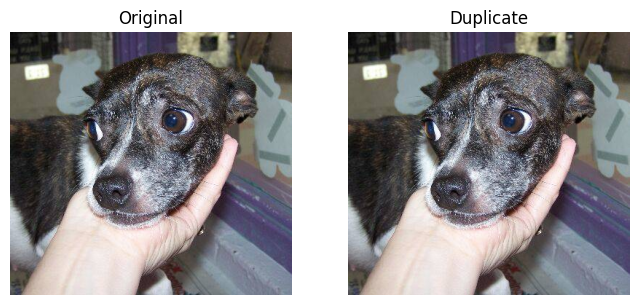

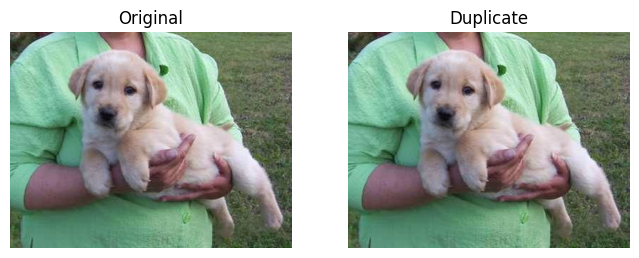

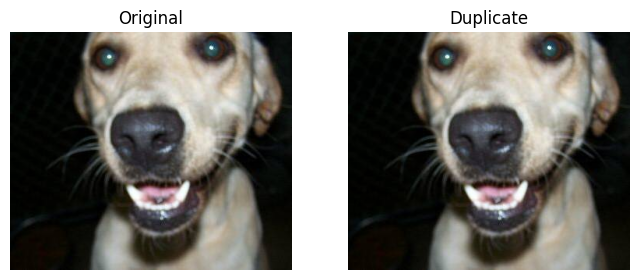

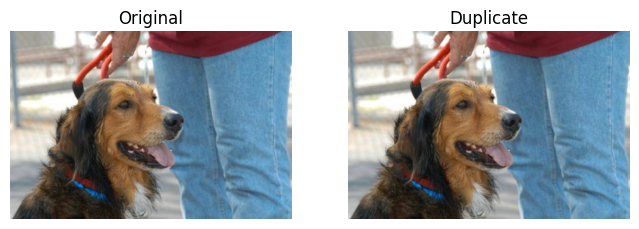

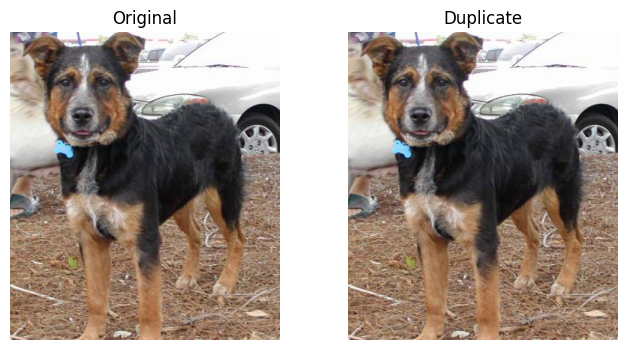

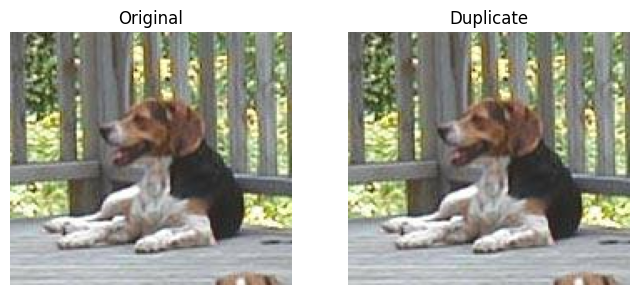

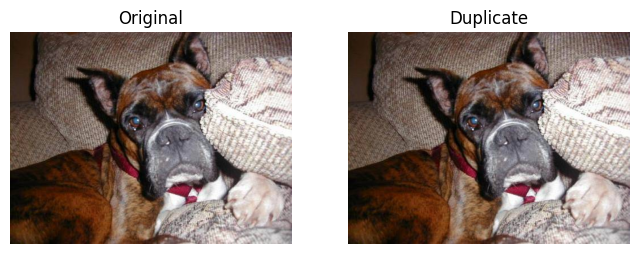

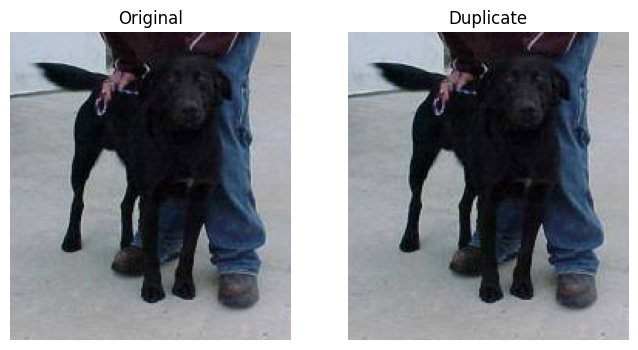

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

# Show first 3 duplicate pairs
for original, duplicate in duplicate_images[:]:

    fig, axes = plt.subplots(1, 2, figsize=(8,4))

    axes[0].imshow(Image.open(original))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(Image.open(duplicate))
    axes[1].set_title("Duplicate")
    axes[1].axis("off")

    plt.show()

In [27]:
# =====================================================
# SECTION 20 : MOVE DUPLICATE IMAGES
# =====================================================

import shutil
from pathlib import Path

# Backup folder
backup_folder = DATASET_PATH / "duplicate_images"
backup_folder.mkdir(exist_ok=True)

moved_count = 0

for original, duplicate in duplicate_images:

    destination = backup_folder / duplicate.name

    shutil.move(str(duplicate), str(destination))

    moved_count += 1

print("=" * 50)
print("DUPLICATE IMAGE CLEANUP")
print("=" * 50)
print(f"Moved {moved_count} duplicate images to:")
print(backup_folder)

DUPLICATE IMAGE CLEANUP
Moved 8 duplicate images to:
/content/drive/MyDrive/AI-DEEP learning/CNN Cats and Dogs/Cats_Dogs-20260722T141144Z-1-001/Cats_Dogs/duplicate_images
